#### Using auto regression to answer: What is the forecasted incidence of OHCA till year 2040, based on Pan-Asian Resuscitation Outcomes Study (PAROS) data?

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg

In [18]:
# read from the collated incident count csv
OHCA_incident_count = pd.read_csv("../../datasets/OHCA_incidents_count.csv")
OHCA_incident_count.head()

,Year,Incident Count (Year),Quarter,Incident Count (Quarter),Month,Incident Count (Month)
0,2010.0,1081.0,2010Q2,348.0,2010-04,102
1,2011.0,1377.0,2010Q3,335.0,2010-05,126
2,2012.0,1440.0,2010Q4,398.0,2010-06,120
3,2013.0,1736.0,2011Q1,411.0,2010-07,95
4,2014.0,2038.0,2011Q2,356.0,2010-08,135


##### Spliting the dataset

In [19]:
# copy the dataframe so python does not give a warning 
count_by_month = OHCA_incident_count[["Month", "Incident Count (Month)"]].copy()
# convert to date format
count_by_month["Month"] = pd.to_datetime(count_by_month["Month"]) + pd.offsets.MonthEnd(0)

training_df = count_by_month[count_by_month["Month"].dt.year <= 2019]
testing_df = count_by_month[count_by_month["Month"].dt.year >= 2020]

print(training_df)
print(testing_df)

         Month  Incident Count (Month)
0   2010-04-30                     102
1   2010-05-31                     126
2   2010-06-30                     120
3   2010-07-31                      95
4   2010-08-31                     135
..         ...                     ...
112 2019-08-31                     258
113 2019-09-30                     252
114 2019-10-31                     271
115 2019-11-30                     282
116 2019-12-31                     332

[117 rows x 2 columns]
         Month  Incident Count (Month)
117 2020-01-31                     309
118 2020-02-29                     261
119 2020-03-31                     275
120 2020-04-30                     272
121 2020-05-31                     298
122 2020-06-30                     270
123 2020-07-31                     265
124 2020-08-31                     307
125 2020-09-30                     266
126 2020-10-31                     276
127 2020-11-30                     314
128 2020-12-31                     318
1

##### Performing Autoregression

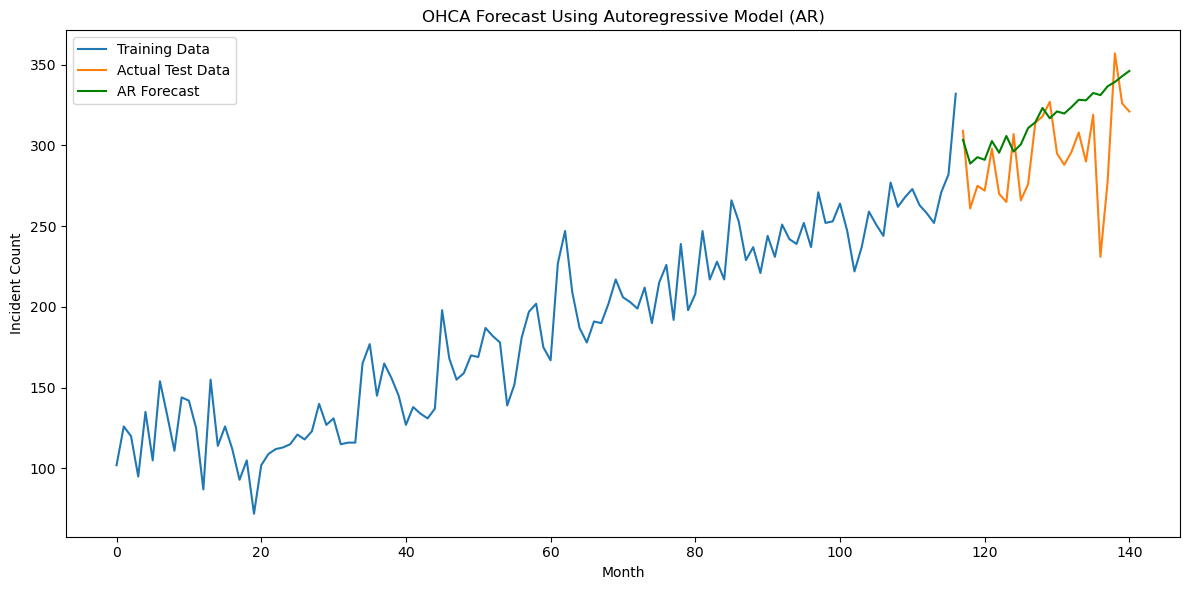

In [41]:
# training data
train_series = training_df['Incident Count (Month)']

# fit AR model with lag = 12 (monthly seasonality)
model = AutoReg(train_series, lags=12).fit()

# Forecast 24 months (2020–2021)
n_periods = len(testing_df)
# forecast_df = model.predict(start=len(train_series), end=len(train_series) + n_periods - 1)

# # Align index with test period
# forecast_df.index = testing_df.index

forecast_df = pd.DataFrame({
    "Month": testing_df.index,
    "Forecast": model.predict(start=len(train_series), end=len(train_series) + n_periods - 1).values
}).set_index("Month")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_series, label='Training Data')
plt.plot(testing_df['Incident Count (Month)'], label='Actual Test Data')
plt.plot(forecast_df["Forecast"], label='AR Forecast', color='green')
plt.title('OHCA Forecast Using Autoregressive Model (AR)')
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.legend()
plt.tight_layout()
plt.show()

##### Evaluating forecast accuracy

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = testing_df["Incident Count (Month)"]
y_predicted = forecast_df["Forecast"]

mae = mean_absolute_error(y_true, y_predicted)
rmse = np.sqrt(mean_squared_error(y_true, y_predicted))

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

MAE: 25.53
RMSE: 32.69
